In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
df.shape

(45000, 14)

In [ ]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
#identify duplicate records
print("number of duplicate rows:",df.duplicated().sum())

number of duplicate rows: 0


In [ ]:
#null values identification
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [ ]:

df = pd.read_csv('/content/loan_data.csv')

In [ ]:

df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1


In [ ]:
print(df.shape)

(45000, 14)


In [ ]:
print(df.describe())


         person_age  person_income  person_emp_exp     loan_amnt  \
count  45000.000000   4.500000e+04    45000.000000  45000.000000   
mean      27.764178   8.031905e+04        5.410333   9583.157556   
std        6.045108   8.042250e+04        6.063532   6314.886691   
min       20.000000   8.000000e+03        0.000000    500.000000   
25%       24.000000   4.720400e+04        1.000000   5000.000000   
50%       26.000000   6.704800e+04        4.000000   8000.000000   
75%       30.000000   9.578925e+04        8.000000  12237.250000   
max      144.000000   7.200766e+06      125.000000  35000.000000   

       loan_int_rate  loan_percent_income  cb_person_cred_hist_length  \
count   45000.000000         45000.000000                45000.000000   
mean       11.006606             0.139725                    5.867489   
std         2.978808             0.087212                    3.879702   
min         5.420000             0.000000                    2.000000   
25%         8.590000  

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:

print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


In [ ]:
le = LabelEncoder()
categorical_cols_to_encode = [
    'person_gender',
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]

for col in categorical_cols_to_encode:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
        print(f"Encoded '{col}'. Unique values: {df[col].unique()}")


Encoded 'person_gender'. Unique values: [0 1]
Encoded 'person_education'. Unique values: [4 3 1 0 2]
Encoded 'person_home_ownership'. Unique values: [3 2 0 1]
Encoded 'loan_intent'. Unique values: [4 1 3 5 2 0]
Encoded 'previous_loan_defaults_on_file'. Unique values: [0 1]


In [ ]:
print("\nDataset After Encoding Categorical Features:")
print(df.head())



Dataset After Encoding Categorical Features:
   person_age  person_gender  person_education  person_income  person_emp_exp  \
0        22.0              0                 4        71948.0               0   
1        21.0              0                 3        12282.0               0   
2        25.0              0                 3        12438.0               3   
3        23.0              0                 1        79753.0               0   
4        24.0              1                 4        66135.0               1   

   person_home_ownership  loan_amnt  loan_intent  loan_int_rate  \
0                      3    35000.0            4          16.02   
1                      2     1000.0            1          11.14   
2                      0     5500.0            3          12.87   
3                      3    35000.0            3          15.23   
4                      3    35000.0            3          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score

In [ ]:
# OUTLIER DETECTION


sns.boxplot(dataset['person_income'])

plt.xlabel('Person Income')

plt.title('Boxplot of Person Income')

plt.show()


# DEFINE CATEGORICAL COLUMNS

categorical_columns = [
    'person_gender',
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]


# ENCODE CATEGORICAL VARIABLES


label_encoder = LabelEncoder()

for column in categorical_columns:

    dataset[column] = label_encoder.fit_transform(
        dataset[column]
    )


# DISPLAY DATASET AFTER ENCODING

print("\nDataset after Encoding:")

print(dataset.head())

In [ ]:
# Outlier Detection - Loan Amount (using correct column name)
Q1_loan = df['loan_amnt'].quantile(0.25)
Q3_loan = df['loan_amnt'].quantile(0.75)
IQR_loan = Q3_loan - Q1_loan
lower_limit_loan = Q1_loan - 1.5 * IQR_loan
upper_limit_loan = Q3_loan + 1.5 * IQR_loan
print("\nLoan Amount (loan_amnt) Lower Limit:", lower_limit_loan)
print("Loan Amount (loan_amnt) Upper Limit:", upper_limit_loan)
outliers_loan = df[(df['loan_amnt'] < lower_limit_loan) |(df['loan_amnt'] > upper_limit_loan)]
print("\nLoan Amount (loan_amnt) Outliers:")
print(outliers_loan.shape)



Loan Amount (loan_amnt) Lower Limit: -5855.875
Loan Amount (loan_amnt) Upper Limit: 23093.125

Loan Amount (loan_amnt) Outliers:
(2348, 14)


In [ ]:
# Define Features X and Target y
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [ ]:
# Feature Scaling
scaler = StandardScaler()
cols_to_scale = ['person_age','person_income','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']
cols_to_scale = [
    col for col in cols_to_scale
    if col in X_train.columns]

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
print("\nFirst 5 rows of scaled X_train:")
print(X_train.head())



First 5 rows of scaled X_train:
       person_age  person_gender  person_education  person_income  \
6048    -0.622502              1                 4      -0.256600   
3346    -0.787921              0                 3      -0.411269   
17998    0.204591              0                 4       1.902342   
24988    0.370009              0                 1       0.186994   
23231    0.204591              1                 1      -0.089147   

       person_emp_exp  person_home_ownership  loan_amnt  loan_intent  \
6048        -0.561597                      2  -0.823150            5   
3346        -0.561597                      3   0.224243            5   
17998        0.262920                      0   0.065547            5   
24988        0.757630                      0  -0.569236            3   
23231        0.262920                      0  -0.251845            4   

       loan_int_rate  loan_percent_income  cb_person_cred_hist_length  \
6048       -1.687749            -0.800883     

In [ ]:
# Model Building
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
print("\nLogistic Regression Model:")
print(model)


Logistic Regression Model:
LogisticRegression(max_iter=1000, random_state=42)


In [ ]:

# Predictions on Test Data
y_pred = model.predict(X_test)

In [ ]:
# Training and Testing Accuracy
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print("\nTraining Accuracy :", train_accuracy)
print("Testing Accuracy :", test_accuracy)


Training Accuracy : 0.8897777777777778
Testing Accuracy : 0.8966666666666666


In [ ]:

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

TN, FP, FN, TP = cm.ravel()
print("\nTrue Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)


Confusion Matrix:
[[6569  431]
 [ 499 1501]]

True Negative (TN): 6569
False Positive (FP): 431
False Negative (FN): 499
True Positive (TP): 1501


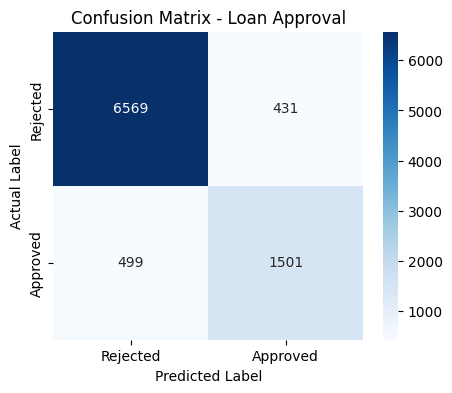

In [ ]:
# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Loan Approval")
plt.show()

In [ ]:
# Classification Report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7000
           1       0.78      0.75      0.76      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000



In [ ]:
# ROC Curve and AUC
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
print("\nAUC Score :", auc_score)


AUC Score : 0.9513889285714285


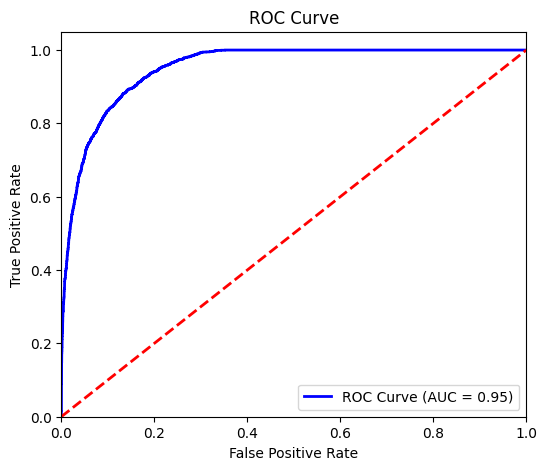

In [ ]:

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(
    fpr,
    tpr,
    color='blue',
    lw=2,
    label='ROC Curve (AUC = %0.2f)' % auc_score
)
plt.plot(
    [0, 1],
    [0, 1],
    color='red',
    lw=2,
    linestyle='--'
)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

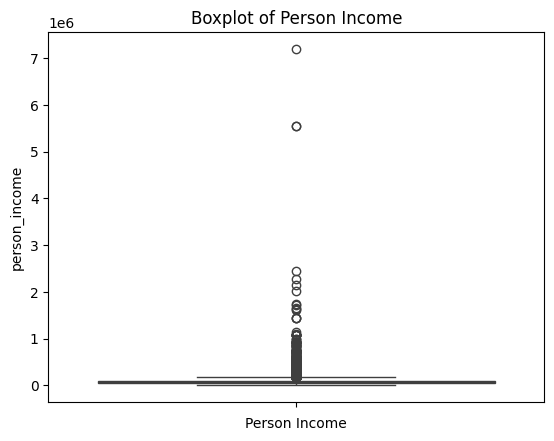


Dataset after Encoding:
   person_age  person_gender  person_education  person_income  person_emp_exp  \
0        22.0              0                 4        71948.0               0   
1        21.0              0                 3        12282.0               0   
2        25.0              0                 3        12438.0               3   
3        23.0              0                 1        79753.0               0   
4        24.0              1                 4        66135.0               1   

   person_home_ownership  loan_amnt  loan_intent  loan_int_rate  \
0                      3    35000.0            4          16.02   
1                      2     1000.0            1          11.14   
2                      0     5500.0            3          12.87   
3                      3    35000.0            3          15.23   
4                      3    35000.0            3          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                

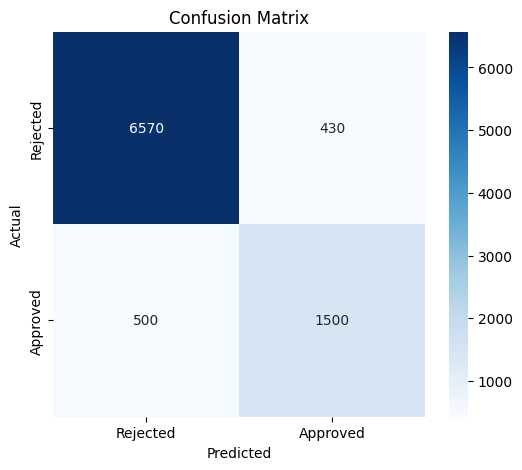


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7000
           1       0.78      0.75      0.76      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000


AUC Score: 0.9513860000000001


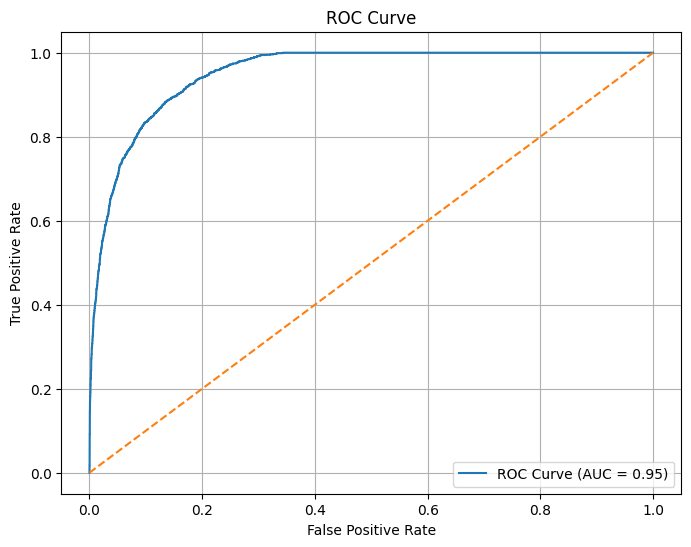

In [ ]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)



# READ DATASET


dataset = pd.read_csv('/content/loan_data.csv')


# DATASET INFORMATIOn
dataset.info()



# STATISTICAL SUMMARY
dataset.describe()



# DISPLAY FIRST FIVE ROWS


dataset.head()



# DISPLAY LAST FIVE ROWS

dataset.tail()



# DATASET SHAPE


dataset.shape

# DISPLAY DATASET


dataset



# CHECK DUPLICATE RECORDS


print("Duplicate Records:",
      dataset.duplicated().sum())


# CHECK MISSING VALUES

print("\nMissing Values:")

print(dataset.isnull().sum())



# OUTLIER DETECTION


sns.boxplot(dataset['person_income'])

plt.xlabel('Person Income')

plt.title('Boxplot of Person Income')

plt.show()


# DEFINE CATEGORICAL COLUMNS

categorical_columns = [
    'person_gender',
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]


# ENCODE CATEGORICAL VARIABLES


label_encoder = LabelEncoder()

for column in categorical_columns:

    dataset[column] = label_encoder.fit_transform(
        dataset[column]
    )


# DISPLAY DATASET AFTER ENCODING

print("\nDataset after Encoding:")

print(dataset.head())



# FEATURE ENGINEERING


dataset['Loan_Income_Ratio'] = (
    dataset['loan_amnt'] /
    dataset['person_income']
)


# DEFINE INDEPENDENT AND DEPENDENT VARIABLES


x = dataset.drop(
    'loan_status',
    axis=1
)

y = dataset['loan_status']


print("\nIndependent Variables:")

print(x.columns)

print("\nDependent Variable:")

print(y.name)


# SPLIT DATASET INTO TRAINING AND TESTING SETS

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print(
    f"Number of instances for training: {len(x_train)}"
)

print(
    f"Number of instances for testing: {len(x_test)}"
)



# FEATURE SCALING

scaler = StandardScaler()

x_train = scaler.fit_transform(
    x_train
)

x_test = scaler.transform(
    x_test
)



# LOGISTIC REGRESSION MODEL
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)



# TRAIN THE MODEL


model.fit(
    x_train,
    y_train
)

print("Model Trained Successfully")



# PREDICT TEST DATA


y_pred = model.predict(
    x_test
)



# DISPLAY ACTUAL AND PREDICTED VALUES


df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(df)


# EVALUATE MODEL PERFORMANCE ON TRAINING DATA


y_train_pred = model.predict(
    x_train
)

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

train_precision = precision_score(
    y_train,
    y_train_pred
)

train_recall = recall_score(
    y_train,
    y_train_pred
)


print("\n========== TRAINING PERFORMANCE ==========")

print(
    "Accuracy:",
    train_accuracy
)

print(
    "Precision:",
    train_precision
)

print(
    "Recall:",
    train_recall
)



# EVALUATE MODEL PERFORMANCE ON TESTING DATA


test_accuracy = accuracy_score(
    y_test,
    y_pred
)

test_precision = precision_score(
    y_test,
    y_pred
)

test_recall = recall_score(
    y_test,
    y_pred
)


print("\n========== TESTING PERFORMANCE ==========")

print(
    "Accuracy:",
    test_accuracy
)

print(
    "Precision:",
    test_precision
)

print(
    "Recall:",
    test_recall
)



# CONFUSION MATRIX


cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")

print(cm)



# CONFUSION MATRIX VISUALIZATION


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()


# CLASSIFICATION REPORT
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ROC-AUC


y_probability = model.predict_proba(
    x_test
)[:, 1]


auc_score = roc_auc_score(
    y_test,
    y_probability
)


print("\nAUC Score:",
      auc_score)


# ROC CURVE

fpr, tpr, threshold = roc_curve(
    y_test,
    y_probability
)


plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label='ROC Curve (AUC = {:.2f})'.format(
        auc_score
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.grid(True)

plt.show()